#Aashma Dangol

Worksheet 02: Image Classification Using Softmax Regression

1. Softmax Function

In [ ]:
import numpy as np

# -------------------------------
# Softmax Function
# -------------------------------
def softmax(z):
    """
    Compute the softmax probabilities for input matrix z
    """
    # Numerical stability
    z_stable = z - np.max(z, axis=1, keepdims=True)

    exp_z = np.exp(z_stable)
    softmax_output = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return softmax_output


# -------------------------------
# Test Case
# -------------------------------
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("✅ Softmax function passed!")

✅ Softmax function passed!


2. Prediction Function

In [ ]:
# -------------------------------
# Prediction Function
# -------------------------------
def predict_softmax(X, W, b):
    """
    Predict class labels using softmax
    """
    z = np.dot(X, W) + b
    probs = softmax(z)

    predicted_classes = np.argmax(probs, axis=1)

    return predicted_classes


# -------------------------------
# Test Case
# -------------------------------
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)

assert y_pred_test.shape == (3,), "Shape mismatch"

print("✅ Predicted classes:", y_pred_test)

✅ Predicted classes: [1 1 0]


3. Loss Function (Cross-Entropy)

In [ ]:
# -------------------------------
# Loss Function
# -------------------------------
def loss_softmax(y_pred, y):
    """
    Cross-entropy loss
    """
    epsilon = 1e-15  # avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.sum(y * np.log(y_pred)) / y.shape[0]

    return loss


# -------------------------------
# Test Case
# -------------------------------
y_true = np.array([[1,0,0],[0,1,0],[0,0,1]])

y_pred_correct = np.array([
    [0.9,0.05,0.05],
    [0.1,0.85,0.05],
    [0.05,0.1,0.85]
])

y_pred_wrong = np.array([
    [0.05,0.05,0.9],
    [0.1,0.05,0.85],
    [0.85,0.1,0.05]
])

loss_correct = loss_softmax(y_pred_correct, y_true)
loss_wrong = loss_softmax(y_pred_wrong, y_true)

assert loss_correct < loss_wrong

print("✅ Loss works!")

✅ Loss works!


4. Cost Function

In [ ]:
# -------------------------------
# Cost Function
# -------------------------------
def cost_softmax(X, y, W, b):
    n = X.shape[0]

    z = np.dot(X, W) + b
    y_pred = softmax(z)

    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    total_loss = -np.sum(y * np.log(y_pred))

    return total_loss / n


# -------------------------------
# Test Case
# -------------------------------
X_correct = np.array([[1.0,0.0],[0.0,1.0]])
y_correct = np.array([[1,0],[0,1]])
W_correct = np.array([[5,-2],[-3,5]])
b_correct = np.array([0.1,0.1])

X_wrong = np.array([[0.1,0.9],[0.8,0.2]])
y_wrong = np.array([[1,0],[0,1]])
W_wrong = np.array([[0.1,2.0],[1.5,0.3]])
b_wrong = np.array([0.5,0.6])

cost1 = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost2 = cost_softmax(X_wrong, y_wrong, W_wrong, b_wrong)

assert cost2 > cost1

print("✅ Cost function works!")

✅ Cost function works!


5. Compute Gradient

In [ ]:
# -------------------------------
# Gradient Computation
# -------------------------------
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]

    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

6. Gradient Descent

In [ ]:
# -------------------------------
# Gradient Descent
# -------------------------------
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):

        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost}")

    return W, b, cost_history

7. Load & Prepare MNIST Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# -------------------------------
# Plot Sample Images
# -------------------------------
def plot_sample_images(X, y):
    plt.figure(figsize=(10,4))

    unique_classes = np.unique(y)

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28,28)

        plt.subplot(2,5,i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# -------------------------------
# Load Dataset
# -------------------------------
def load_and_prepare_mnist(csv_file):
    df = pd.read_csv(csv_file)

    y = df.iloc[:,0].values
    X = df.iloc[:,1:].values

    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

8. Train Model

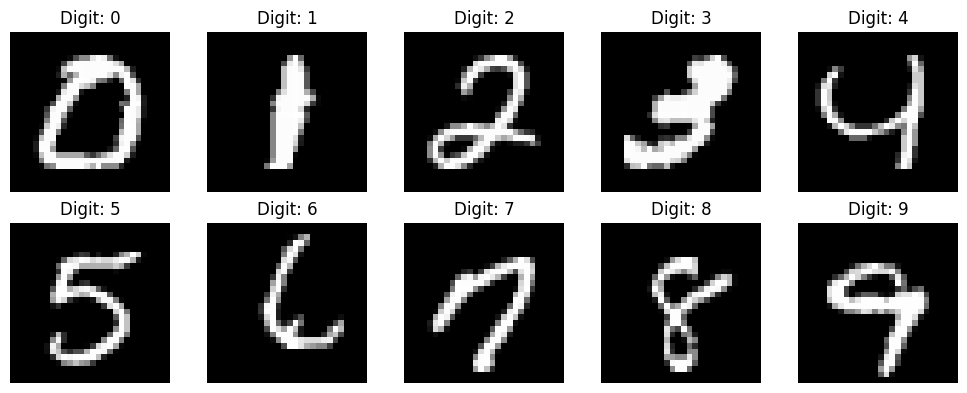

Iteration 0: Cost = 2.205733304824849
Iteration 100: Cost = 0.5972599093084137
Iteration 200: Cost = 0.4778295556181001
Iteration 300: Cost = 0.42801854669407097
Iteration 400: Cost = 0.39900961590331624
Iteration 500: Cost = 0.3793884440988864
Iteration 600: Cost = 0.3649324861448373
Iteration 700: Cost = 0.35367539771497625
Iteration 800: Cost = 0.3445624191945102
Iteration 900: Cost = 0.33697044555911604


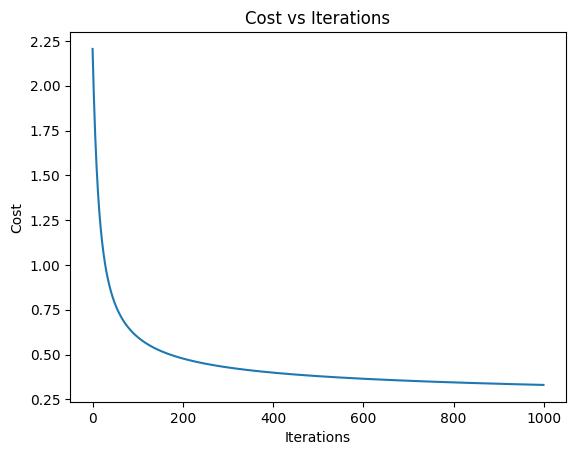

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Call the load_and_prepare_mnist function to get the data
X_train, X_test, y_train, y_test = load_and_prepare_mnist('sample_data/mnist_train_small.csv')

# One-hot encode
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1,1))
y_test = encoder.transform(y_test.reshape(-1,1))

d = X_train.shape[1]
c = y_train.shape[1]

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 1000

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot cost
plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

9. Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Predict
y_pred = predict_softmax(X_test, W_opt, b_opt)
y_true = np.argmax(y_test, axis=1)

# Metrics
cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Confusion Matrix:
 [[359   0   3   1   1   3   4   1   5   0]
 [  0 426   1   4   1   2   0   1   1   0]
 [  3   1 346   2  10   1   6   7   9   5]
 [  3   1  11 359   0  15   0   4   7   6]
 [  1   2   6   1 366   0   7   1   1  16]
 [  4   4   5  22   3 277   8   1  13   4]
 [  1   1  13   1   4   9 379   0   3   1]
 [  2   4   6   3   4   0   1 401   3  14]
 [  4   9   8  10   3  23   2   5 318   2]
 [  2   5   1   5  20   4   0   7   5 366]]
Precision: 0.8990512969332694
Recall: 0.89925
F1: 0.8990038297346371


10. Logistic Regression (Separability Task)

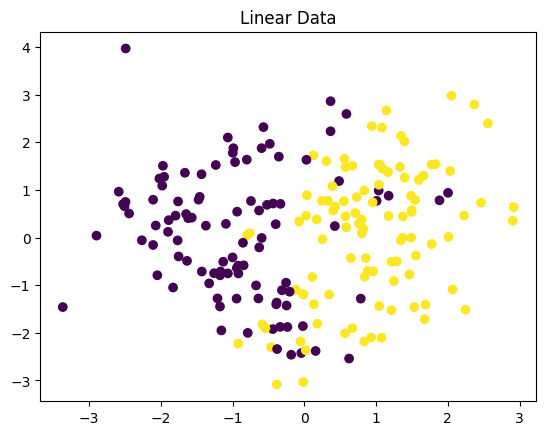

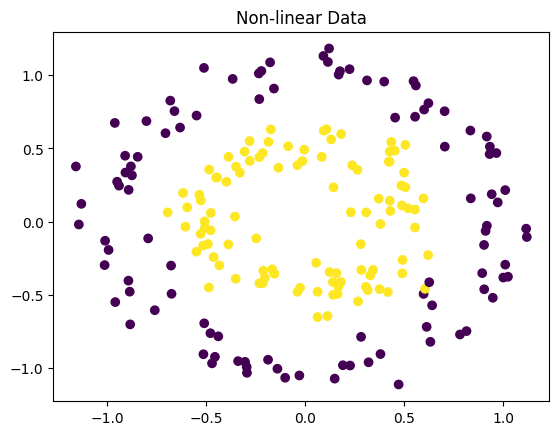

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

# Linear data
X_lin, y_lin = make_classification(n_samples=200, n_features=2, n_informative=2,
                                  n_redundant=0, random_state=42)

# Non-linear data
X_non, y_non = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

model_lin = LogisticRegression().fit(X_lin, y_lin)
model_non = LogisticRegression().fit(X_non, y_non)

plt.scatter(X_lin[:,0], X_lin[:,1], c=y_lin)
plt.title("Linear Data")
plt.show()

plt.scatter(X_non[:,0], X_non[:,1], c=y_non)
plt.title("Non-linear Data")
plt.show()